***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.5 图像质量评估与测量](9_5_image_assessment_and_measurement.ipynb)
    * 下一节： [9.7 谱线数据处理](9_7_spectral_line_processing.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.6 时间平均、频率平均与展宽

在真实处理里，为了减小数据量，人们经常会沿时间或频率做平均。但平均并不是免费的：

- 离相位中心越远的源，条纹旋转越快；
- 基线越长，条纹旋转越快；
- 通道越宽、积分时间越长，平均造成的相位涂抹就越严重。

因此平均会把离轴源变暗、拉宽，最终降低宽场成像的保真度。这一节给出几个最常见的定量趋势。


***


In [2]:
c = 299792458.0
omega_earth = 7.2921159e-5


def bandwidth_attenuation(theta_rad, baseline_m, channel_width_hz, freq_hz):
    argument = np.pi * baseline_m * theta_rad * channel_width_hz / c
    return np.sinc(argument / np.pi)


def time_attenuation(theta_rad, baseline_m, tint_s, freq_hz, dec_deg=45.0):
    wavelength = c / freq_hz
    projected_rate = omega_earth * (baseline_m / wavelength) * np.cos(np.deg2rad(dec_deg))
    argument = np.pi * projected_rate * theta_rad * tint_s
    return np.sinc(argument / np.pi)


field_angle_arcmin = np.linspace(0.0, 45.0, 240)
theta = np.deg2rad(field_angle_arcmin / 60.0)
baseline_set = [150.0, 1000.0, 5000.0]
freq_hz = 1.4e9

tint_set = [2.0, 10.0, 60.0]
channel_width_set = [0.5e6, 2.0e6, 8.0e6]


### 9.6.1 基线越长、离轴越远，平均损失越严重


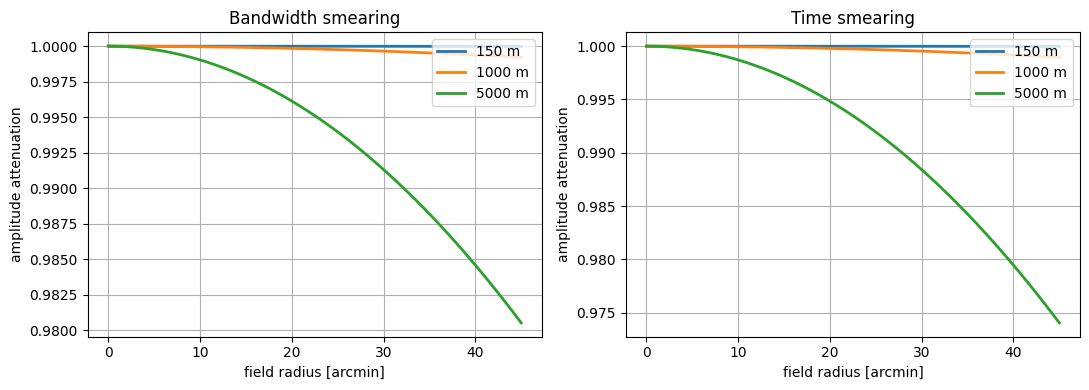

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

for baseline_m in baseline_set:
    axes[0].plot(
        field_angle_arcmin,
        bandwidth_attenuation(theta, baseline_m, channel_width_hz=0.5e6, freq_hz=freq_hz),
        lw=2.0,
        label=f"{baseline_m:.0f} m",
    )
    axes[1].plot(
        field_angle_arcmin,
        time_attenuation(theta, baseline_m, tint_s=8.0, freq_hz=freq_hz),
        lw=2.0,
        label=f"{baseline_m:.0f} m",
    )

axes[0].set_xlabel("field radius [arcmin]")
axes[0].set_ylabel("amplitude attenuation")
axes[0].set_title("Bandwidth smearing")
axes[0].legend(loc="upper right")

axes[1].set_xlabel("field radius [arcmin]")
axes[1].set_ylabel("amplitude attenuation")
axes[1].set_title("Time smearing")
axes[1].legend(loc="upper right")

plt.tight_layout()


这两个趋势都说明一个共同事实：**宽场成像最怕把长基线数据平均得过粗。** 因为长基线本来就对离轴源最敏感，平均以后会最快丢失保真度。


### 9.6.2 通道宽度与积分时间的实际权衡


在 20 arcmin 视场半径、5000 m 基线上的衰减：
  Δν = 0.500 MHz -> 0.996
  Δν = 2.000 MHz -> 0.939
  Δν = 8.000 MHz -> 0.265
  Δt = 2 s -> 1.000
  Δt = 10 s -> 0.992
  Δt = 60 s -> 0.734


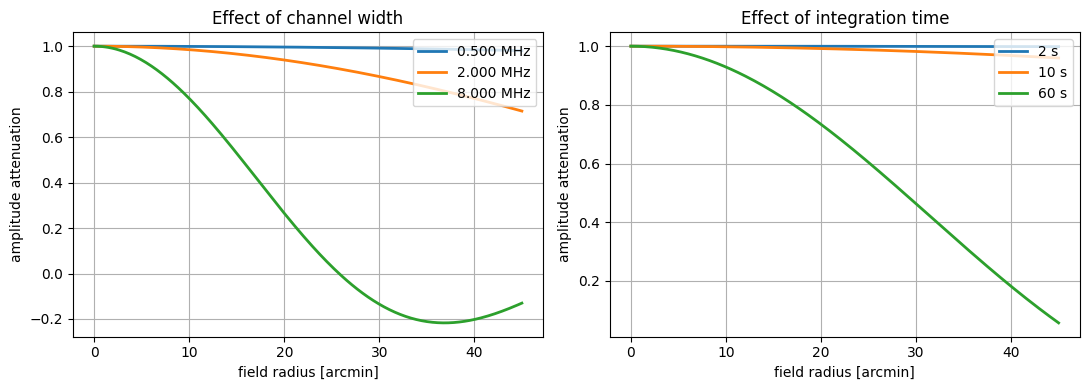

In [4]:
test_radius = np.deg2rad(20.0 / 60.0)
baseline_m = 5000.0

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

for dnu in channel_width_set:
    att = bandwidth_attenuation(theta, baseline_m, channel_width_hz=dnu, freq_hz=freq_hz)
    axes[0].plot(field_angle_arcmin, att, lw=2.0, label=f"{dnu/1e6:.3f} MHz")

for tint in tint_set:
    att = time_attenuation(theta, baseline_m, tint_s=tint, freq_hz=freq_hz)
    axes[1].plot(field_angle_arcmin, att, lw=2.0, label=f"{tint:.0f} s")

axes[0].set_xlabel("field radius [arcmin]")
axes[0].set_ylabel("amplitude attenuation")
axes[0].set_title("Effect of channel width")
axes[0].legend(loc="upper right")

axes[1].set_xlabel("field radius [arcmin]")
axes[1].set_ylabel("amplitude attenuation")
axes[1].set_title("Effect of integration time")
axes[1].legend(loc="upper right")

plt.tight_layout()

print("在 20 arcmin 视场半径、5000 m 基线上的衰减：")
for dnu in channel_width_set:
    print(f"  Δν = {dnu/1e6:.3f} MHz -> {bandwidth_attenuation(test_radius, baseline_m, dnu, freq_hz):.3f}")
for tint in tint_set:
    print(f"  Δt = {tint:.0f} s -> {time_attenuation(test_radius, baseline_m, tint, freq_hz):.3f}")


### 9.6.3 一个简单的“可接受视场”估算

若把“幅度衰减不超过 5%”作为一个经验阈值，那么给定基线长度、通道宽度和积分时间后，可以倒推出允许的最大视场半径。这个估算虽然粗糙，但在做 `split` 或 `mstransform` 平均前很有用。


In [5]:
def max_radius_for_threshold(func, baseline_m, threshold, **kwargs):
    radii = np.deg2rad(np.linspace(0.0, 60.0, 2000) / 60.0)
    attenuation = func(radii, baseline_m, **kwargs)
    valid = np.where(attenuation >= threshold)[0]
    if valid.size == 0:
        return 0.0
    return np.rad2deg(radii[valid[-1]]) * 60.0


radius_bw = max_radius_for_threshold(
    bandwidth_attenuation,
    baseline_m=5000.0,
    threshold=0.95,
    channel_width_hz=2.0e6,
    freq_hz=freq_hz,
)
radius_time = max_radius_for_threshold(
    time_attenuation,
    baseline_m=5000.0,
    threshold=0.95,
    tint_s=24.0,
    freq_hz=freq_hz,
)

print(f"带宽展宽 5% 阈值对应的最大视场半径约为 {radius_bw:.1f} arcmin")
print(f"时间展宽 5% 阈值对应的最大视场半径约为 {radius_time:.1f} arcmin")


带宽展宽 5% 阈值对应的最大视场半径约为 18.1 arcmin
时间展宽 5% 阈值对应的最大视场半径约为 20.9 arcmin


这也是为什么宽场、高动态范围数据并不适合“为了省空间而随手平均”。一旦平均过头，后面再怎么校准和 CLEAN，都不能把已经在相关器或预处理里损失掉的离轴信息完全找回来。
